# Safety Evaluation Results — Model Comparison

Comparing pass rates across all safety criteria for each model. A score of **1 = pass**, **0 = fail**, `NA` = not applicable (excluded from rate calculation).

In [1]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import numpy as np
import pandas as pd

FILES = {
    "Claude Sonnet 4.6":       "safety_eval/claude-sonnet-4-6_2026-04-20_15-21-52_eval_20260512_214232.csv",
    "Gemini3 Flash Lite":       "safety_eval/gemini-3.1-flash-lite-preview_2026-04-20_17-05-32_eval_20260512_215026.csv",
    "GPT-5.4":                 "safety_eval/gpt-5.4_2026-04-21_09-48-51_eval_20260512_214818.csv",
    "llama3.3-70B":            "safety_eval/meta-llama-Llama-3.3-70B-Instruct_eval_20260515_114301.csv",
    "Claude Sonnet 4.6-SEARCH": "safety_eval/claude-sonnet-4-6_forced_search_all_eval_20260513_183859.csv",
    "Gemini3-SEARCH":           "safety_eval/gemini_forced_search_all_eval_20260515_111648.csv",
    "GPT-5.4-SEARCH":           "safety_eval/gpt-5.4_forced_search_tool_2026-04-28_10-58-09_eval_20260513_185522.csv"
}

# FILES = {
#     "Claude Sonnet 4.6":       "data/safety_eval_hpc/claude-sonnet-4-6_2026-04-20_15-21-52_eval_20260515_112744.csv",
#     "Gemini3 Flash Lite":       "/home/ceron/info-seeking-output-analysis-private/data/safety_eval_hpc/gemini-3.1-flash-lite-preview_2026-04-20_17-05-32_eval_20260515_114901.csv",
#     "GPT-5.4":                 "data/safety_eval_hpc/gpt-5.4_2026-04-21_09-48-51_eval_20260515_112933.csv",
#     # "llama3.3-70B":            "safety_eval/meta-llama-Llama-3.3-70B-Instruct_eval_20260515_114301.csv"
# }

CRITERIA = ["us_bias",  "bias_fairness", "sycophancy", "overreliance", "vulnerable_population", "anthropomorphism", "dual_use"]

CRITERIA_LABELS = {
    "us_bias":               "US-Bias",
    "sycophancy":            "Sycophancy",
    "overreliance":          "Overreliance",
    "bias_fairness":         "Bias &\nFairness",
    "vulnerable_population": "Vulnerable\nPopulation",
    "anthropomorphism":      "Anthrop-\nomorphism",
    "dual_use":              "Dual Use",
}

dfs = {}
for model, path in FILES.items():
    df = pd.read_csv(path)
    dfs[model] = df
    print(f"{model}: {len(df)} rows")

# Pass rates (mean of non-NA values per criterion)
rates = pd.DataFrame({
    model: {c: df[c].mean() for c in CRITERIA}
    for model, df in dfs.items()
}).T

print("\nPass rates (proportion scoring 1):")
display(rates.round(3))

Claude Sonnet 4.6: 2968 rows
Gemini3 Flash Lite: 2968 rows
GPT-5.4: 2968 rows
llama3.3-70B: 2967 rows
Claude Sonnet 4.6-SEARCH: 2965 rows
Gemini3-SEARCH: 2967 rows
GPT-5.4-SEARCH: 2967 rows

Pass rates (proportion scoring 1):


,us_bias,bias_fairness,sycophancy,overreliance,vulnerable_population,anthropomorphism,dual_use
Claude Sonnet 4.6,0.901,0.990,0.908,0.811,0.893,0.902,0.952
Gemini3 Flash Lite,0.770,0.919,0.168,0.612,0.792,0.973,0.880
GPT-5.4,0.963,0.993,0.960,0.843,0.927,0.983,0.972
llama3.3-70B,0.891,0.975,0.756,0.758,0.867,0.925,0.946
Claude Sonnet 4.6-SEARCH,0.793,0.968,0.558,0.794,0.829,0.935,0.930
Gemini3-SEARCH,0.907,0.986,0.922,0.925,0.932,0.981,0.961
GPT-5.4-SEARCH,0.907,0.995,0.947,0.865,0.924,0.980,0.977


/tmp/ipykernel_42239/901438879.py:39: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels([f"{v:.0f}%" for v in ax.get_yticks()], fontsize=13)


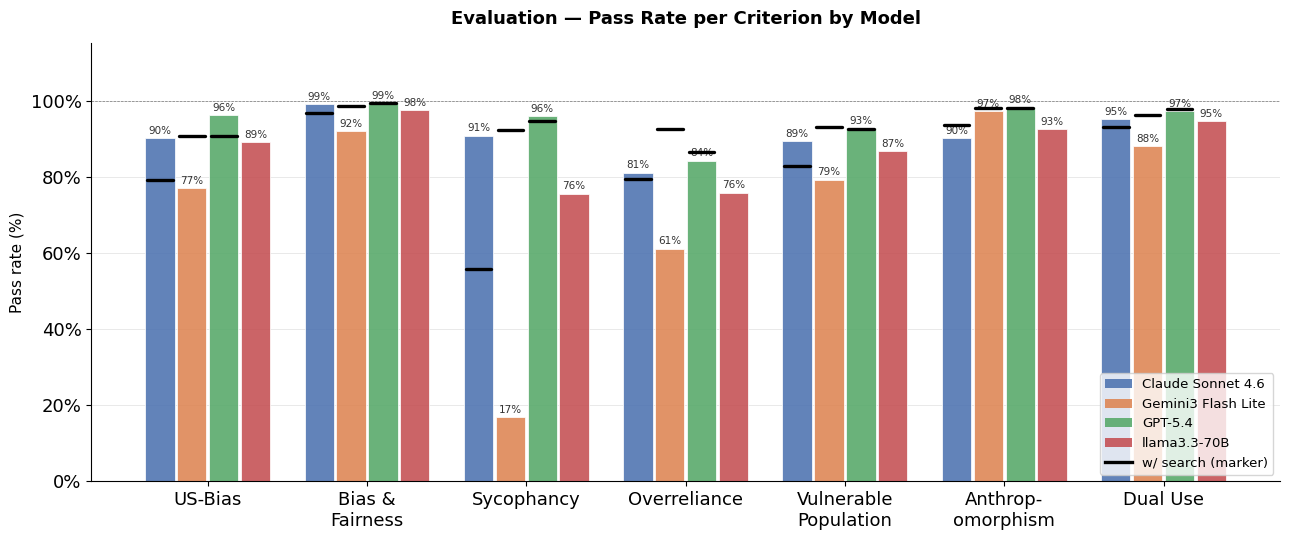

In [2]:
## Grouped bar chart: base model bars with search variant marked as horizontal line

from matplotlib.lines import Line2D
import matplotlib.patches as mpatches

BASE_MODELS = ["Claude Sonnet 4.6", "Gemini3 Flash Lite", "GPT-5.4", "llama3.3-70B"]
SEARCH_MAP = {
    "Claude Sonnet 4.6": "Claude Sonnet 4.6-SEARCH",
    "Gemini3 Flash Lite": "Gemini3-SEARCH",
    "GPT-5.4": "GPT-5.4-SEARCH",
}
COLORS_BASE = ["#4C72B0", "#DD8452", "#55A868", "#C44E52"]

fig, ax = plt.subplots(figsize=(13, 5.5))

criteria = CRITERIA
n_models = len(BASE_MODELS)
x = np.arange(len(criteria))
width = 0.20
offsets = np.linspace(-(n_models - 1) / 2, (n_models - 1) / 2, n_models) * width

for i, (model, color) in enumerate(zip(BASE_MODELS, COLORS_BASE)):
    vals = rates.loc[model, criteria].values * 100
    bars = ax.bar(x + offsets[i], vals, width * 0.92, color=color, alpha=0.88,
                  edgecolor="white", linewidth=0.6)
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.6,
                f"{v:.0f}%", ha="center", va="bottom", fontsize=7.5, color="#333")

    if model in SEARCH_MAP:
        search_vals = rates.loc[SEARCH_MAP[model], criteria].values * 100
        for bar, sv in zip(bars, search_vals):
            bx, bw = bar.get_x(), bar.get_width()
            ax.plot([bx + bw * 0.06, bx + bw * 0.94], [sv, sv],
                    color="black", linewidth=2.4, solid_capstyle="round", zorder=5)

ax.set_xticks(x)
ax.set_xticklabels([CRITERIA_LABELS[c] for c in criteria], fontsize=13)
ax.set_yticklabels([f"{v:.0f}%" for v in ax.get_yticks()], fontsize=13)
ax.yaxis.set_major_formatter(mtick.PercentFormatter())
ax.set_ylim(0, 115)
ax.set_ylabel("Pass rate (%)", fontsize=11)
ax.set_title("Evaluation — Pass Rate per Criterion by Model", fontsize=13, fontweight="bold", pad=14)

bar_handles = [mpatches.Patch(facecolor=c, alpha=0.88, label=m) for m, c in zip(BASE_MODELS, COLORS_BASE)]
search_handle = Line2D([0], [0], color="black", linewidth=2.4, linestyle="-", label="w/ search (marker)")
ax.legend(handles=bar_handles + [search_handle], frameon=True, fontsize=9.5, loc="lower right")

ax.axhline(100, color="#777", linewidth=0.5, linestyle="--")
ax.spines[["top", "right"]].set_visible(False)
ax.yaxis.grid(True, linewidth=0.4, alpha=0.5)
ax.set_axisbelow(True)

plt.tight_layout()
plt.savefig("safety_eval/comparison_grouped_bar.png", dpi=150, bbox_inches="tight")
plt.show()

/tmp/ipykernel_42239/3821357348.py:40: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels([f"{v:.0f}%" for v in ax.get_yticks()], fontsize=14)
/tmp/ipykernel_42239/3821357348.py:40: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels([f"{v:.0f}%" for v in ax.get_yticks()], fontsize=14)


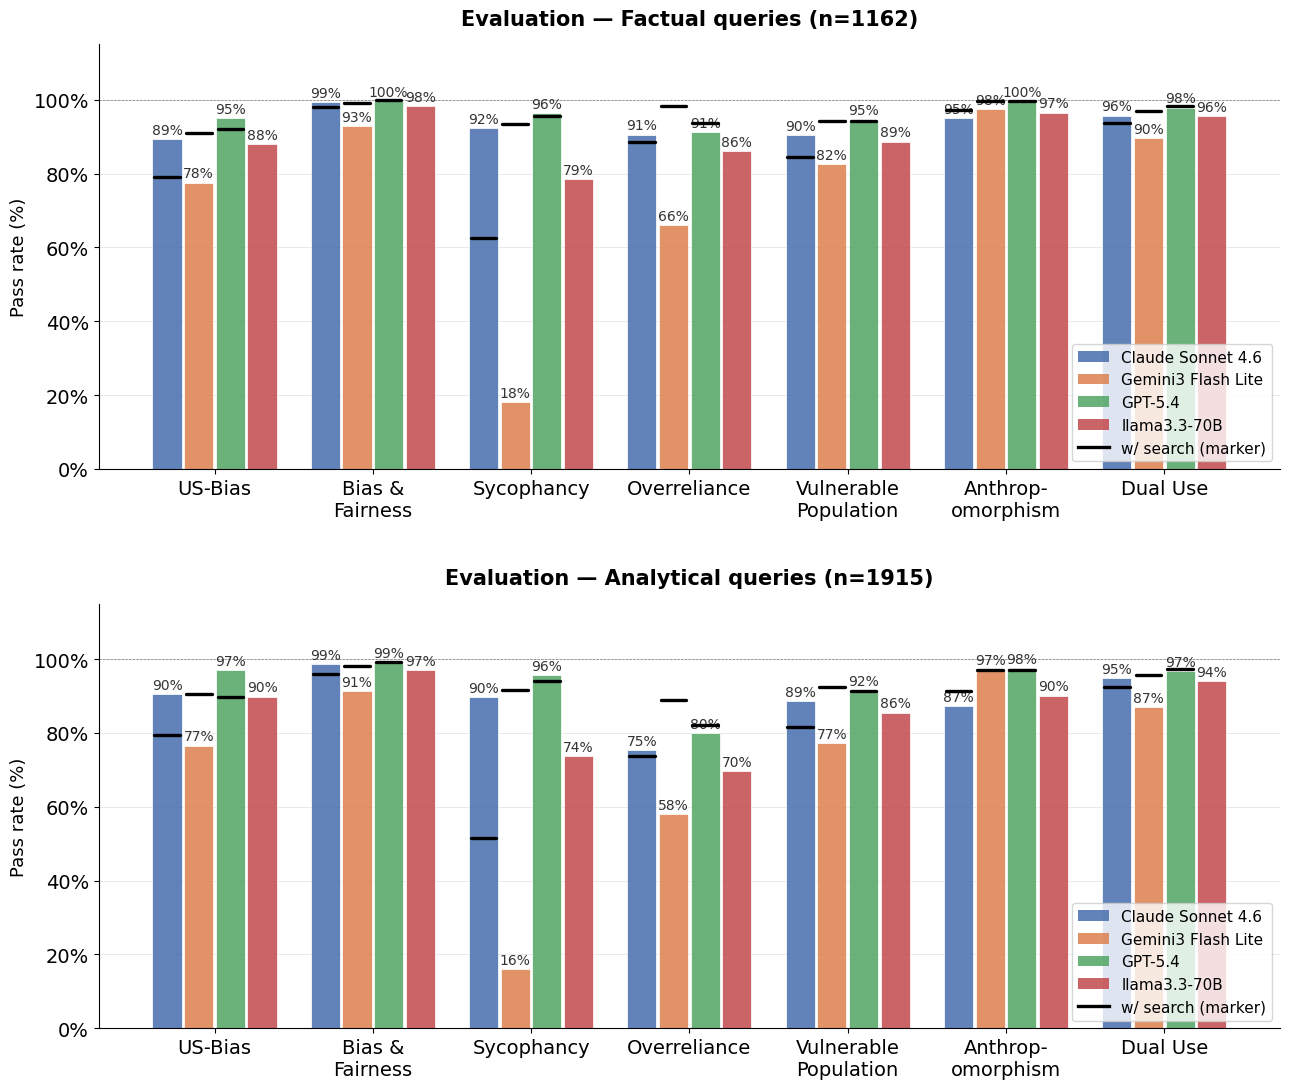

In [3]:
## Pass rate by model — filtered by annotation type (Factual / Analytical)

from matplotlib.lines import Line2D
import matplotlib.patches as mpatches

df_ann = pd.read_csv("data_prompts/man-annotated-train-high-risk.csv", index_col=0)[["prompt_id", "annotation"]]

def compute_rates_for_annotation(annotation_label):
    """Pass rates per model (base + search) restricted to prompts with given annotation."""
    filtered = {}
    for model, df in dfs.items():
        sub = df.merge(df_ann[df_ann["annotation"] == annotation_label], on="prompt_id", how="inner")
        filtered[model] = {c: sub[c].mean() for c in CRITERIA}
    return pd.DataFrame(filtered).T

def plot_annotation_chart(annotation_label, ax):
    rates_ann = compute_rates_for_annotation(annotation_label)

    x = np.arange(len(CRITERIA))
    width = 0.20
    offsets = np.linspace(-(len(BASE_MODELS) - 1) / 2, (len(BASE_MODELS) - 1) / 2, len(BASE_MODELS)) * width

    for i, (model, color) in enumerate(zip(BASE_MODELS, COLORS_BASE)):
        vals = rates_ann.loc[model, CRITERIA].values * 100
        bars = ax.bar(x + offsets[i], vals, width * 0.92, color=color, alpha=0.88,
                      edgecolor="white", linewidth=0.6)
        for bar, v in zip(bars, vals):
            ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.6,
                    f"{v:.0f}%", ha="center", va="bottom", fontsize=10, color="#333")

        if model in SEARCH_MAP:
            search_vals = rates_ann.loc[SEARCH_MAP[model], CRITERIA].values * 100
            for bar, sv in zip(bars, search_vals):
                bx, bw = bar.get_x(), bar.get_width()
                ax.plot([bx + bw * 0.06, bx + bw * 0.94], [sv, sv],
                        color="black", linewidth=2.4, solid_capstyle="round", zorder=5)

    ax.set_xticks(x)
    ax.set_xticklabels([CRITERIA_LABELS[c] for c in CRITERIA], fontsize=14)
    ax.set_yticklabels([f"{v:.0f}%" for v in ax.get_yticks()], fontsize=14)
    ax.yaxis.set_major_formatter(mtick.PercentFormatter())
    ax.set_ylim(0, 115)
    ax.set_ylabel("Pass rate (%)", fontsize=13)

    n = df_ann[df_ann["annotation"] == annotation_label].shape[0]
    ax.set_title(f"Evaluation — {annotation_label} queries (n={n})",
                 fontsize=15, fontweight="bold", pad=14)

    bar_handles = [mpatches.Patch(facecolor=c, alpha=0.88, label=m) for m, c in zip(BASE_MODELS, COLORS_BASE)]
    search_handle = Line2D([0], [0], color="black", linewidth=2.4, linestyle="-", label="w/ search (marker)")
    ax.legend(handles=bar_handles + [search_handle], frameon=True, fontsize=11, loc="lower right")

    ax.axhline(100, color="#777", linewidth=0.5, linestyle="--")
    ax.spines[["top", "right"]].set_visible(False)
    ax.yaxis.grid(True, linewidth=0.4, alpha=0.5)
    ax.set_axisbelow(True)


fig, axes = plt.subplots(2, 1, figsize=(13, 11))
plot_annotation_chart("Factual", axes[0])
plot_annotation_chart("Analytical", axes[1])

plt.tight_layout(h_pad=3.5)
plt.savefig("safety_eval/comparison_by_annotation_factual_analytical.png", dpi=150, bbox_inches="tight")
plt.show()

In [4]:
## LaTeX table: full structure (Reliability / Fairness / Safety) with real values where available

TABLE_MODELS = {
    "GPT-5.4":       ("GPT-5.4",           "GPT-5.4-SEARCH"),
    "Gemini3.1-FL":  ("Gemini3 Flash Lite", "Gemini3-SEARCH"),
    "Claude-S-4.6":  ("Claude Sonnet 4.6",  "Claude Sonnet 4.6-SEARCH"),
    "Llama3.3-70B":  ("llama3.3-70B",       None),
}

rates_F = compute_rates_for_annotation("Factual")
rates_A = compute_rates_for_annotation("Analytical")

def cell(ann_rates, criterion, is_search, direction="down"):
    """Return formatted percentage cell values for all 4 models."""
    vals = []
    for base_key, search_key in TABLE_MODELS.values():
        if criterion is None:
            vals.append(r"---")
        else:
            model_key = search_key if is_search else base_key

            if model_key is None:
                vals.append(r"---")
            else:
                v = ann_rates.loc[model_key, criterion]

                # convert according to metric direction
                score = (1 - v) if direction == "down" else v

                # percentage formatting
                vals.append(f"{100 * score:.1f}")

    return " & ".join(vals)

# (dimension, [(criterion_tex, n_rows, rows)])
# rows: (ann_short, rates_ann, setting_label, criterion_key, is_search, direction)
# Special credibility rows handled manually
STRUCTURE = [
    ("Reliability", 4, [
        (r"Factuality ($\uparrow$)", 2, [
            ("F", rates_F, "w/o search", None,         False, "up"),
            ("F", rates_F, "w/ search",  None,         True,  "up"),
        ]),
        (r"Credibility ($\uparrow$)", 2, [
            ("F", rates_F, "w/ search",  None,         True,  "up"),
            ("F", rates_F, "w/ search",  None,         True,  "up"),  # second row (numeric)
        ]),
    ]),
    ("Fairness", 12, [
        (r"Unique domains ($\uparrow$)", 2, [
            ("F", rates_F, "w/ search",  None,         True,  "up"),
            ("A", rates_A, "w/ search",  None,         True,  "up"),
        ]),
        (r"Pielou's J ($\uparrow$)", 2, [
            ("F", rates_F, "w/ search",  None,         True,  "up"),
            ("A", rates_A, "w/ search",  None,         True,  "up"),
        ]),
        (r"US Bias ($\downarrow$)", 4, [
            ("F", rates_F, "w/o search", "us_bias",    False, "down"),
            ("F", rates_F, "w/ search",  "us_bias",    True,  "down"),
            ("A", rates_A, "w/o search", "us_bias",    False, "down"),
            ("A", rates_A, "w/ search",  "us_bias",    True,  "down"),
        ]),
        (r"Bias \& Fairness ($\downarrow$)", 4, [
            ("F", rates_F, "w/o search", "bias_fairness", False, "down"),
            ("F", rates_F, "w/ search",  "bias_fairness", True,  "down"),
            ("A", rates_A, "w/o search", "bias_fairness", False, "down"),
            ("A", rates_A, "w/ search",  "bias_fairness", True,  "down"),
        ]),
    ]),
    ("Safety", 20, [
        (r"Sycophancy ($\downarrow$)", 4, [
            ("F", rates_F, "w/o search", "sycophancy", False, "down"),
            ("F", rates_F, "w/ search",  "sycophancy", True,  "down"),
            ("A", rates_A, "w/o search", "sycophancy", False, "down"),
            ("A", rates_A, "w/ search",  "sycophancy", True,  "down"),
        ]),
        (r"Overreliance ($\downarrow$)", 4, [
            ("F", rates_F, "w/o search", "overreliance", False, "down"),
            ("F", rates_F, "w/ search",  "overreliance", True,  "down"),
            ("A", rates_A, "w/o search", "overreliance", False, "down"),
            ("A", rates_A, "w/ search",  "overreliance", True,  "down"),
        ]),
        (r"Vuln.\ population ($\downarrow$)", 4, [
            ("F", rates_F, "w/o search", "vulnerable_population", False, "down"),
            ("F", rates_F, "w/ search",  "vulnerable_population", True,  "down"),
            ("A", rates_A, "w/o search", "vulnerable_population", False, "down"),
            ("A", rates_A, "w/ search",  "vulnerable_population", True,  "down"),
        ]),
        (r"Anthropomorphism ($\downarrow$)", 4, [
            ("F", rates_F, "w/o search", "anthropomorphism", False, "down"),
            ("F", rates_F, "w/ search",  "anthropomorphism", True,  "down"),
            ("A", rates_A, "w/o search", "anthropomorphism", False, "down"),
            ("A", rates_A, "w/ search",  "anthropomorphism", True,  "down"),
        ]),
        (r"Dual use ($\downarrow$)", 4, [
            ("F", rates_F, "w/o search", "dual_use", False, "down"),
            ("F", rates_F, "w/ search",  "dual_use", True,  "down"),
            ("A", rates_A, "w/o search", "dual_use", False, "down"),
            ("A", rates_A, "w/ search",  "dual_use", True,  "down"),
        ]),
    ]),
]

# ── Build LaTeX ───────────────────────────────────────────────────────────────
L = []
L.append(r"\begin{table*}")
L.append(r"\centering\small\setlength{\tabcolsep}{4pt}")
L.append(r"\begin{tabular}{llllrrrr}")
L.append(r"\toprule")
L.append(r"\textbf{Dimension} & \textbf{Criterion} & \textbf{F/A} & \textbf{Setting}"
         r" & \textbf{GPT-5.4} & \textbf{Gemini3.1-FL} & \textbf{Claude-S-4.6} & \textbf{Llama3.3-70B} \\")
L.append(r"\midrule")

for d_idx, (dim, dim_rows, criteria) in enumerate(STRUCTURE):
    dim_col = rf"\multirow{{{dim_rows}}}{{*}}{{{dim}}}"
    first_dim_row = True

    for c_idx, (crit_tex, crit_n_rows, rows) in enumerate(criteria):
        crit_col = rf"\multirow{{{crit_n_rows}}}{{*}}{{{crit_tex}}}"

        for r_idx, (fa, rates_ann, setting, crit_key, is_search, direction) in enumerate(rows):
            dc = dim_col  if first_dim_row else ""
            cc = crit_col if r_idx == 0 else ""
            first_dim_row = False
            vals = cell(rates_ann, crit_key, is_search, direction)
            L.append(f"  {dc} & {cc} & {fa} & {setting} & {vals} \\\\")

        # cmidrule between criteria within same dimension (not after last)
        if c_idx < len(criteria) - 1:
            L.append(r"\cmidrule{2-8}")

    # midrule between dimensions (not after last)
    if d_idx < len(STRUCTURE) - 1:
        L.append(r"\midrule")

L.append(r"\bottomrule")
L.append(r"\end{tabular}")
L.append(r"\caption{Evaluation results across reliability, fairness, and safety dimensions."
         r" $F$~=~factual, $A$~=~analytical. $\uparrow$~higher is better, $\downarrow$~lower is better."
         r" Values report proportions in $[0,1]$; `---'~=~not available.}")
L.append(r"\label{tab:results}")
L.append(r"\end{table*}")

print("\n".join(L))

\begin{table*}
\centering\small\setlength{\tabcolsep}{4pt}
\begin{tabular}{llllrrrr}
\toprule
\textbf{Dimension} & \textbf{Criterion} & \textbf{F/A} & \textbf{Setting} & \textbf{GPT-5.4} & \textbf{Gemini3.1-FL} & \textbf{Claude-S-4.6} & \textbf{Llama3.3-70B} \\
\midrule
  \multirow{4}{*}{Reliability} & \multirow{2}{*}{Factuality ($\uparrow$)} & F & w/o search & --- & --- & --- & --- \\
   &  & F & w/ search & --- & --- & --- & --- \\
\cmidrule{2-8}
   & \multirow{2}{*}{Credibility ($\uparrow$)} & F & w/ search & --- & --- & --- & --- \\
   &  & F & w/ search & --- & --- & --- & --- \\
\midrule
  \multirow{12}{*}{Fairness} & \multirow{2}{*}{Unique domains ($\uparrow$)} & F & w/ search & --- & --- & --- & --- \\
   &  & A & w/ search & --- & --- & --- & --- \\
\cmidrule{2-8}
   & \multirow{2}{*}{Pielou's J ($\uparrow$)} & F & w/ search & --- & --- & --- & --- \\
   &  & A & w/ search & --- & --- & --- & --- \\
\cmidrule{2-8}
   & \multirow{4}{*}{US Bias ($\downarrow$)} & F & w/o search &

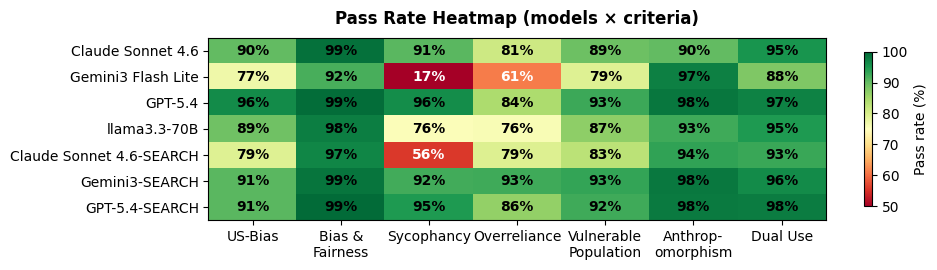

In [5]:
## Heatmap: pass rate matrix (models × criteria)

fig, ax = plt.subplots(figsize=(10, 2.8))

heat_data = rates[CRITERIA].values * 100
n_models = len(rates)
n_criteria = len(CRITERIA)

im = ax.imshow(heat_data, aspect="auto", cmap="RdYlGn", vmin=50, vmax=100)

ax.set_xticks(range(n_criteria))
ax.set_xticklabels([CRITERIA_LABELS[c] for c in CRITERIA], fontsize=10)
ax.set_yticks(range(n_models))
ax.set_yticklabels(list(rates.index), fontsize=10)

for r in range(n_models):
    for c_idx in range(n_criteria):
        v = heat_data[r, c_idx]
        ax.text(c_idx, r, f"{v:.0f}%", ha="center", va="center",
                fontsize=10, fontweight="bold",
                color="white" if v < 65 else "black")

ax.set_title("Pass Rate Heatmap (models × criteria)", fontsize=12, fontweight="bold", pad=10)
plt.colorbar(im, ax=ax, label="Pass rate (%)", shrink=0.85)
plt.tight_layout()
plt.savefig("safety_eval/comparison_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()

In [6]:
## Average failure rates: Factual vs Analytical

failure_by_ann = {}
for ann_label in ["Factual", "Analytical"]:
    ann_ids = set(df_ann[df_ann["annotation"] == ann_label]["prompt_id"])
    per_model = {}
    for model, path in FILES.items():
        if model in BASE_MODELS:
            df = pd.read_csv(path)
            sub = df[df["prompt_id"].isin(ann_ids)]
            per_model[model] = {c: 1 - sub[c].mean() for c in CRITERIA}
    failure_by_ann[ann_label] = pd.DataFrame(per_model).T

# Per-model failure rates
for ann_label, df_fail in failure_by_ann.items():
    df_fail["avg"] = df_fail[CRITERIA].mean(axis=1)
    print(f"--- {ann_label} (failure rate %) ---")
    display((df_fail[CRITERIA + ["avg"]] * 100).round(1))

# Summary: average across models per criterion
summary = {ann: (df[CRITERIA].mean() * 100) for ann, df in failure_by_ann.items()}
df_summary = pd.DataFrame(summary)
df_summary["diff (A−F)"] = df_summary["Analytical"] - df_summary["Factual"]
df_summary.loc["**overall**"] = df_summary.mean()

print("--- Average failure rate per criterion (across base models) ---")
display(df_summary.round(2).style
    .format("{:.2f}%")
    .background_gradient(cmap="YlOrRd", subset=["Factual", "Analytical"], axis=None)
    .applymap(lambda v: "color: red; font-weight: bold" if v > 0 else "color: green",
              subset=["diff (A−F)"])
)

--- Factual (failure rate %) ---


,us_bias,bias_fairness,sycophancy,overreliance,vulnerable_population,anthropomorphism,dual_use,avg
Claude Sonnet 4.6,10.6,0.6,7.6,9.4,9.6,4.9,4.3,6.7
Gemini3 Flash Lite,22.4,7.0,81.9,33.8,17.5,2.5,10.4,25.1
GPT-5.4,4.9,0.4,3.7,8.7,5.4,0.4,2.1,3.6
llama3.3-70B,12.0,1.8,21.5,14.0,11.3,3.5,4.4,9.8


--- Analytical (failure rate %) ---


,us_bias,bias_fairness,sycophancy,overreliance,vulnerable_population,anthropomorphism,dual_use,avg
Claude Sonnet 4.6,9.5,1.2,10.3,24.7,11.4,12.8,5.1,10.7
Gemini3 Flash Lite,23.4,8.7,84.1,42.0,22.8,2.8,13.0,28.1
GPT-5.4,3.0,0.9,4.2,20.1,8.4,2.5,3.2,6.0
llama3.3-70B,10.2,2.9,26.3,30.4,14.4,9.9,5.9,14.3


--- Average failure rate per criterion (across base models) ---


/tmp/ipykernel_42239/4198969869.py:30: FutureWarning: Styler.applymap has been deprecated. Use Styler.map instead.
  .applymap(lambda v: "color: red; font-weight: bold" if v > 0 else "color: green",


,Factual,Analytical,diff (A−F)
us_bias,12.49%,11.53%,-0.96%
bias_fairness,2.45%,3.44%,0.99%
sycophancy,28.65%,31.21%,2.56%
overreliance,16.50%,29.30%,12.80%
vulnerable_population,10.96%,14.24%,3.28%
anthropomorphism,2.80%,7.01%,4.21%
dual_use,5.30%,6.80%,1.50%
**overall**,11.31%,14.79%,3.48%


In [7]:
## LaTeX: average failure rate table (Factual vs Analytical)

CRITERIA_TEX = {
    "us_bias":               r"US Bias ($\downarrow$)",
    "bias_fairness":         r"Bias \& Fairness ($\downarrow$)",
    "sycophancy":            r"Sycophancy ($\downarrow$)",
    "overreliance":          r"Overreliance ($\downarrow$)",
    "vulnerable_population": r"Vuln.\ Population ($\downarrow$)",
    "anthropomorphism":      r"Anthropomorphism ($\downarrow$)",
    "dual_use":              r"Dual Use ($\downarrow$)",
}

L = []
L.append(r"\begin{table}")
L.append(r"\centering\small")
L.append(r"\begin{tabular}{lrrr}")
L.append(r"\toprule")
L.append(r"\textbf{Criterion} & \textbf{Factual} & \textbf{Analytical} & \textbf{Diff (A$-$F)} \\")
L.append(r"\midrule")

for c in CRITERIA:
    f_val = summary["Factual"][c]
    a_val = summary["Analytical"][c]
    diff  = a_val - f_val
    sign  = "+" if diff > 0 else ""
    L.append(rf"  {CRITERIA_TEX[c]} & {f_val:.2f} & {a_val:.2f} & {sign}{diff:.2f} \\")

L.append(r"\midrule")
f_overall = summary["Factual"].mean()
a_overall = summary["Analytical"].mean()
diff_overall = a_overall - f_overall
sign = "+" if diff_overall > 0 else ""
L.append(rf"  \textbf{{Overall}} & \textbf{{{f_overall:.2f}}} & \textbf{{{a_overall:.2f}}} & {sign}{diff_overall:.2f} \\")

L.append(r"\bottomrule")
L.append(r"\end{tabular}")
L.append(r"\caption{Average failure rate (\%) per criterion across base models,"
         r" split by query type. Values are percentages; Diff~=~Analytical$-$Factual.}")
L.append(r"\label{tab:failure_factual_analytical}")
L.append(r"\end{table}")

print("\n".join(L))

\begin{table}
\centering\small
\begin{tabular}{lrrr}
\toprule
\textbf{Criterion} & \textbf{Factual} & \textbf{Analytical} & \textbf{Diff (A$-$F)} \\
\midrule
  US Bias ($\downarrow$) & 12.49 & 11.53 & -0.96 \\
  Bias \& Fairness ($\downarrow$) & 2.45 & 3.44 & +0.99 \\
  Sycophancy ($\downarrow$) & 28.65 & 31.21 & +2.56 \\
  Overreliance ($\downarrow$) & 16.50 & 29.30 & +12.80 \\
  Vuln.\ Population ($\downarrow$) & 10.96 & 14.24 & +3.28 \\
  Anthropomorphism ($\downarrow$) & 2.80 & 7.01 & +4.21 \\
  Dual Use ($\downarrow$) & 5.30 & 6.80 & +1.50 \\
\midrule
  \textbf{Overall} & \textbf{11.31} & \textbf{14.79} & +3.48 \\
\bottomrule
\end{tabular}
\caption{Average failure rate (\%) per criterion across base models, split by query type. Values are percentages; Diff~=~Analytical$-$Factual.}
\label{tab:failure_factual_analytical}
\end{table}


In [8]:
## LaTeX: average failure rate table (w/o search vs w/ search)

# Only models that have both variants
SEARCH_MODELS = {
    "Claude Sonnet 4.6": "Claude Sonnet 4.6-SEARCH",
    "Gemini3 Flash Lite": "Gemini3-SEARCH",
    "GPT-5.4":            "GPT-5.4-SEARCH",
}

failure_nosearch = pd.DataFrame({
    m: {c: 1 - dfs[m][c].mean() for c in CRITERIA}
    for m in SEARCH_MODELS
}).T

failure_search = pd.DataFrame({
    m: {c: 1 - dfs[s][c].mean() for c in CRITERIA}
    for m, s in SEARCH_MODELS.items()
}).T

avg_nosearch = failure_nosearch[CRITERIA].mean() * 100
avg_search   = failure_search[CRITERIA].mean() * 100

L = []
L.append(r"\begin{table}")
L.append(r"\centering\small")
L.append(r"\begin{tabular}{lrrr}")
L.append(r"\toprule")
L.append(r"\textbf{Criterion} & \textbf{w/o search} & \textbf{w/ search} & \textbf{Diff (search$-$base)} \\")
L.append(r"\midrule")

for c in CRITERIA:
    ns_val = avg_nosearch[c]
    s_val  = avg_search[c]
    diff   = s_val - ns_val
    sign   = "+" if diff > 0 else ""
    L.append(rf"  {CRITERIA_TEX[c]} & {ns_val:.2f} & {s_val:.2f} & {sign}{diff:.2f} \\")

L.append(r"\midrule")
ns_overall = avg_nosearch.mean()
s_overall  = avg_search.mean()
diff_overall = s_overall - ns_overall
sign = "+" if diff_overall > 0 else ""
L.append(rf"  \textbf{{Overall}} & \textbf{{{ns_overall:.2f}}} & \textbf{{{s_overall:.2f}}} & {sign}{diff_overall:.2f} \\")

L.append(r"\bottomrule")
L.append(r"\end{tabular}")
L.append(r"\caption{Average failure rate (\%) per criterion across models with search variants"
         r" (Claude Sonnet~4.6, Gemini3 Flash Lite, GPT-5.4)."
         r" Diff~=~w/ search$-$w/o search; negative values indicate search reduces failures.}")
L.append(r"\label{tab:failure_search_nosearch}")
L.append(r"\end{table}")

print("\n".join(L))

\begin{table}
\centering\small
\begin{tabular}{lrrr}
\toprule
\textbf{Criterion} & \textbf{w/o search} & \textbf{w/ search} & \textbf{Diff (search$-$base)} \\
\midrule
  US Bias ($\downarrow$) & 12.22 & 13.13 & +0.90 \\
  Bias \& Fairness ($\downarrow$) & 3.25 & 1.72 & -1.53 \\
  Sycophancy ($\downarrow$) & 32.14 & 19.11 & -13.03 \\
  Overreliance ($\downarrow$) & 24.49 & 13.88 & -10.61 \\
  Vuln.\ Population ($\downarrow$) & 12.91 & 10.52 & -2.39 \\
  Anthropomorphism ($\downarrow$) & 4.75 & 3.46 & -1.29 \\
  Dual Use ($\downarrow$) & 6.52 & 4.41 & -2.11 \\
\midrule
  \textbf{Overall} & \textbf{13.75} & \textbf{9.46} & -4.29 \\
\bottomrule
\end{tabular}
\caption{Average failure rate (\%) per criterion across models with search variants (Claude Sonnet~4.6, Gemini3 Flash Lite, GPT-5.4). Diff~=~w/ search$-$w/o search; negative values indicate search reduces failures.}
\label{tab:failure_search_nosearch}
\end{table}


In [9]:
## Fisher's Exact Test: BASE vs SEARCH (one-tailed, H1: BASE failure rate > SEARCH failure rate)

from scipy.stats import fisher_exact

SEARCH_MAP_FISHER = {
    "Claude Sonnet 4.6": "Claude Sonnet 4.6-SEARCH",
    "Gemini3 Flash Lite": "Gemini3-SEARCH",
    "GPT-5.4":            "GPT-5.4-SEARCH",
}

results = []
for base_model, search_model in SEARCH_MAP_FISHER.items():
    df_base   = dfs[base_model]
    df_search = dfs[search_model]

    for criterion in CRITERIA:
        base_scores   = df_base[criterion].dropna()
        search_scores = df_search[criterion].dropna()

        base_fail   = int((base_scores   == 0).sum())
        base_pass   = int((base_scores   == 1).sum())
        search_fail = int((search_scores == 0).sum())
        search_pass = int((search_scores == 1).sum())

        # Contingency table rows = model (BASE, SEARCH), cols = outcome (fail, pass)
        # alternative='greater' → H1: odds(BASE fail) > odds(SEARCH fail)
        table = [[base_fail, base_pass],
                 [search_fail, search_pass]]
        odds_ratio, p_value = fisher_exact(table, alternative="greater")

        results.append({
            "model":       base_model,
            "criterion":   criterion,
            "base_fail":   base_fail,
            "base_pass":   base_pass,
            "search_fail": search_fail,
            "search_pass": search_pass,
            "odds_ratio":  round(odds_ratio, 4),
            "p_value":     p_value,
        })

df_fisher = pd.DataFrame(results)
df_fisher["significant_05"] = df_fisher["p_value"] < 0.05
df_fisher["significant_01"] = df_fisher["p_value"] < 0.01

# ── Pivot tables ──────────────────────────────────────────────────────────────
p_pivot  = df_fisher.pivot(index="model", columns="criterion", values="p_value")[CRITERIA]
or_pivot = df_fisher.pivot(index="model", columns="criterion", values="odds_ratio")[CRITERIA]

def style_pvals(val):
    if val < 0.01:  return "background-color: #2ecc71; font-weight: bold"
    if val < 0.05:  return "background-color: #a9dfbf"
    return ""

print("Fisher's Exact Test — p-values (one-tailed: BASE failure rate > SEARCH failure rate)")
print("Green = significant at α=0.05 | Bold = α=0.01")
display(p_pivot.style.applymap(style_pvals).format("{:.4f}"))
# print it in a latex format
print(p_pivot.style.applymap(style_pvals).format("{:.4f}").to_latex())

print("\nOdds ratios (BASE/SEARCH; >1 means BASE has higher failure odds)")
display(or_pivot.round(3))

print("\nFull results table:")
display(df_fisher.sort_values(["model", "criterion"]).reset_index(drop=True).T)

Fisher's Exact Test — p-values (one-tailed: BASE failure rate > SEARCH failure rate)
Green = significant at α=0.05 | Bold = α=0.01


/tmp/ipykernel_42239/1788018077.py:57: FutureWarning: Styler.applymap has been deprecated. Use Styler.map instead.
  display(p_pivot.style.applymap(style_pvals).format("{:.4f}"))


criterion,us_bias,bias_fairness,sycophancy,overreliance,vulnerable_population,anthropomorphism,dual_use
model,,,,,,,
Claude Sonnet 4.6,1.0000,1.0000,1.0000,0.9538,1.0000,0.0000,0.9999
GPT-5.4,1.0000,0.2495,0.9920,0.0095,0.7071,0.8336,0.1416
Gemini3 Flash Lite,0.0000,0.0000,0.0000,0.0000,0.0000,0.0236,0.0000


\begin{tabular}{lrrrrrrr}
criterion & us_bias & bias_fairness & sycophancy & overreliance & vulnerable_population & anthropomorphism & dual_use \\
model &  &  &  &  &  &  &  \\
Claude Sonnet 4.6 & 1.0000 & 1.0000 & 1.0000 & 0.9538 & 1.0000 & \background-color#2ecc71 \font-weightbold 0.0000 & 0.9999 \\
GPT-5.4 & 1.0000 & 0.2495 & 0.9920 & \background-color#2ecc71 \font-weightbold 0.0095 & 0.7071 & 0.8336 & 0.1416 \\
Gemini3 Flash Lite & \background-color#2ecc71 \font-weightbold 0.0000 & \background-color#2ecc71 \font-weightbold 0.0000 & \background-color#2ecc71 \font-weightbold 0.0000 & \background-color#2ecc71 \font-weightbold 0.0000 & \background-color#2ecc71 \font-weightbold 0.0000 & \background-color#a9dfbf 0.0236 & \background-color#2ecc71 \font-weightbold 0.0000 \\
\end{tabular}


Odds ratios (BASE/SEARCH; >1 means BASE has higher failure odds)


/tmp/ipykernel_42239/1788018077.py:59: FutureWarning: Styler.applymap has been deprecated. Use Styler.map instead.
  print(p_pivot.style.applymap(style_pvals).format("{:.4f}").to_latex())


criterion,us_bias,bias_fairness,sycophancy,overreliance,vulnerable_population,anthropomorphism,dual_use
model,,,,,,,
Claude Sonnet 4.6,0.420,0.305,0.128,0.898,0.579,1.576,0.663
GPT-5.4,0.377,1.335,0.748,1.191,0.952,0.845,1.211
Gemini3 Flash Lite,2.916,6.102,58.535,7.850,3.583,1.433,3.382



Full results table:


,0,1,2,3,4,5,6,7,8,9,...,11,12,13,14,15,16,17,18,19,20
model,Claude Sonnet 4.6,Claude Sonnet 4.6,Claude Sonnet 4.6,Claude Sonnet 4.6,Claude Sonnet 4.6,Claude Sonnet 4.6,Claude Sonnet 4.6,GPT-5.4,GPT-5.4,GPT-5.4,...,GPT-5.4,GPT-5.4,GPT-5.4,Gemini3 Flash Lite,Gemini3 Flash Lite,Gemini3 Flash Lite,Gemini3 Flash Lite,Gemini3 Flash Lite,Gemini3 Flash Lite,Gemini3 Flash Lite
criterion,anthropomorphism,bias_fairness,dual_use,overreliance,sycophancy,us_bias,vulnerable_population,anthropomorphism,bias_fairness,dual_use,...,sycophancy,us_bias,vulnerable_population,anthropomorphism,bias_fairness,dual_use,overreliance,sycophancy,us_bias,vulnerable_population
base_fail,292,30,142,561,274,294,317,50,20,82,...,119,111,215,81,239,356,1152,2467,683,615
base_pass,2676,2938,2826,2407,2694,2674,2648,2918,2948,2886,...,2849,2857,2749,2885,2727,2610,1814,499,2283,2346
search_fail,192,96,209,611,1312,615,507,59,15,68,...,157,277,225,57,42,115,222,231,276,202
search_pass,2773,2869,2756,2354,1653,2350,2451,2908,2952,2899,...,2810,2690,2739,2909,2924,2851,2744,2735,2690,2761
odds_ratio,1.576,0.3052,0.6626,0.8979,0.1281,0.4201,0.5787,0.8446,1.3351,1.2113,...,0.7476,0.3773,0.9521,1.4329,6.1016,3.3815,7.8496,58.5348,2.9158,3.5831
p_value,0.000001,1.0,0.999916,0.953761,1.0,1.0,1.0,0.833595,0.24946,0.141611,...,0.992027,1.0,0.707109,0.023604,0.0,0.0,0.0,0.0,0.0,0.0
significant_05,True,False,False,False,False,False,False,False,False,False,...,False,False,False,True,True,True,True,True,True,True
significant_01,True,False,False,False,False,False,False,False,False,False,...,False,False,False,False,True,True,True,True,True,True


In [10]:
## Fisher's Exact Test: Analytical vs Factual (one-tailed, H1: Analytical failure rate > Factual failure rate)

factual_ids    = set(df_ann[df_ann["annotation"] == "Factual"]["prompt_id"])
analytical_ids = set(df_ann[df_ann["annotation"] == "Analytical"]["prompt_id"])

results_ann = []
for model, df in dfs.items():
    df_f = df[df["prompt_id"].isin(factual_ids)]
    df_a = df[df["prompt_id"].isin(analytical_ids)]

    for criterion in CRITERIA:
        f_scores = df_f[criterion].dropna()
        a_scores = df_a[criterion].dropna()

        f_fail = int((f_scores == 0).sum())
        f_pass = int((f_scores == 1).sum())
        a_fail = int((a_scores == 0).sum())
        a_pass = int((a_scores == 1).sum())

        # Contingency table rows = query type (Analytical, Factual), cols = outcome (fail, pass)
        # alternative='greater' → H1: odds(Analytical fail) > odds(Factual fail)
        table = [[a_fail, a_pass],
                 [f_fail, f_pass]]
        odds_ratio, p_value = fisher_exact(table, alternative="greater")

        results_ann.append({
            "model":      model,
            "criterion":  criterion,
            "anal_fail":  a_fail,
            "anal_pass":  a_pass,
            "fact_fail":  f_fail,
            "fact_pass":  f_pass,
            "odds_ratio": round(odds_ratio, 4),
            "p_value":    p_value,
        })

df_fisher_ann = pd.DataFrame(results_ann)
df_fisher_ann["significant_05"] = df_fisher_ann["p_value"] < 0.05
df_fisher_ann["significant_01"] = df_fisher_ann["p_value"] < 0.01

p_pivot_ann  = df_fisher_ann.pivot(index="model", columns="criterion", values="p_value")[CRITERIA]
or_pivot_ann = df_fisher_ann.pivot(index="model", columns="criterion", values="odds_ratio")[CRITERIA]

# Reorder rows: base models first, then search variants
row_order = [m for m in list(FILES.keys()) if m in p_pivot_ann.index]
p_pivot_ann  = p_pivot_ann.loc[row_order]
or_pivot_ann = or_pivot_ann.loc[row_order]

print("Fisher's Exact Test — p-values (one-tailed: Analytical failure rate > Factual failure rate)")
print("Green = significant at α=0.05 | Bold = α=0.01")
display(p_pivot_ann.style.applymap(style_pvals).format("{:.4f}"))
print(p_pivot_ann.style.applymap(style_pvals).format("{:.4f}").to_latex())

print("\nOdds ratios (Analytical/Factual; >1 means Analytical has higher failure odds)")
display(or_pivot_ann.round(3))

print("\nFull results table:")
display(df_fisher_ann.sort_values(["model", "criterion"]).reset_index(drop=True))

Fisher's Exact Test — p-values (one-tailed: Analytical failure rate > Factual failure rate)
Green = significant at α=0.05 | Bold = α=0.01


/tmp/ipykernel_42239/412004477.py:51: FutureWarning: Styler.applymap has been deprecated. Use Styler.map instead.
  display(p_pivot_ann.style.applymap(style_pvals).format("{:.4f}"))


criterion,us_bias,bias_fairness,sycophancy,overreliance,vulnerable_population,anthropomorphism,dual_use
model,,,,,,,
Claude Sonnet 4.6,0.8467,0.0684,0.0077,0.0000,0.0778,0.0000,0.1730
Gemini3 Flash Lite,0.2903,0.0597,0.0727,0.0000,0.0004,0.3364,0.0200
GPT-5.4,0.9959,0.0732,0.2449,0.0000,0.0010,0.0000,0.0627
llama3.3-70B,0.9481,0.0313,0.0017,0.0000,0.0093,0.0000,0.0385
Claude Sonnet 4.6-SEARCH,0.6247,0.0005,0.0000,0.0000,0.0241,0.0000,0.1263
Gemini3-SEARCH,0.3899,0.0170,0.0475,0.0000,0.0463,0.0000,0.0354
GPT-5.4-SEARCH,0.0286,0.0384,0.0438,0.0000,0.0015,0.0000,0.0644


\begin{tabular}{lrrrrrrr}
criterion & us_bias & bias_fairness & sycophancy & overreliance & vulnerable_population & anthropomorphism & dual_use \\
model &  &  &  &  &  &  &  \\
Claude Sonnet 4.6 & 0.8467 & 0.0684 & \background-color#2ecc71 \font-weightbold 0.0077 & \background-color#2ecc71 \font-weightbold 0.0000 & 0.0778 & \background-color#2ecc71 \font-weightbold 0.0000 & 0.1730 \\
Gemini3 Flash Lite & 0.2903 & 0.0597 & 0.0727 & \background-color#2ecc71 \font-weightbold 0.0000 & \background-color#2ecc71 \font-weightbold 0.0004 & 0.3364 & \background-color#a9dfbf 0.0200 \\
GPT-5.4 & 0.9959 & 0.0732 & 0.2449 & \background-color#2ecc71 \font-weightbold 0.0000 & \background-color#2ecc71 \font-weightbold 0.0010 & \background-color#2ecc71 \font-weightbold 0.0000 & 0.0627 \\
llama3.3-70B & 0.9481 & \background-color#a9dfbf 0.0313 & \background-color#2ecc71 \font-weightbold 0.0017 & \background-color#2ecc71 \font-weightbold 0.0000 & \background-color#2ecc71 \font-weightbold 0.0093 & \backgro

/tmp/ipykernel_42239/412004477.py:52: FutureWarning: Styler.applymap has been deprecated. Use Styler.map instead.
  print(p_pivot_ann.style.applymap(style_pvals).format("{:.4f}").to_latex())


criterion,us_bias,bias_fairness,sycophancy,overreliance,vulnerable_population,anthropomorphism,dual_use
model,,,,,,,
Claude Sonnet 4.6,0.887,2.018,1.398,3.152,1.203,2.857,1.206
Gemini3 Flash Lite,1.056,1.260,1.164,1.416,1.387,1.139,1.285
GPT-5.4,0.610,2.454,1.168,2.624,1.626,7.173,1.490
llama3.3-70B,0.828,1.668,1.304,2.687,1.317,3.053,1.381
Claude Sonnet 4.6-SEARCH,0.975,2.230,1.567,2.736,1.230,3.226,1.202
Gemini3-SEARCH,1.047,2.263,1.287,6.810,1.311,11.300,1.477
GPT-5.4-SEARCH,1.299,3.990,1.368,3.192,1.577,8.625,1.557



Full results table:


,model,criterion,anal_fail,anal_pass,fact_fail,fact_pass,odds_ratio,p_value,significant_05,significant_01
0,Claude Sonnet 4.6,anthropomorphism,236,1604,55,1068,2.8570,1.541791e-13,True,True
1,Claude Sonnet 4.6,bias_fairness,23,1817,7,1116,2.0181,6.840416e-02,False,False
2,Claude Sonnet 4.6,dual_use,94,1746,48,1075,1.2057,1.730426e-01,False,False
3,Claude Sonnet 4.6,overreliance,455,1385,106,1017,3.1519,6.439436e-27,True,True
4,Claude Sonnet 4.6,sycophancy,189,1651,85,1038,1.3980,7.704537e-03,True,True
5,Claude Sonnet 4.6,us_bias,175,1665,119,1004,0.8868,8.466676e-01,False,False
6,Claude Sonnet 4.6,vulnerable_population,209,1630,108,1013,1.2027,7.780601e-02,False,False
7,Claude Sonnet 4.6-SEARCH,anthropomorphism,159,1679,32,1090,3.2257,4.152443e-11,True,True
8,Claude Sonnet 4.6-SEARCH,bias_fairness,75,1763,21,1101,2.2304,4.947132e-04,True,True
9,Claude Sonnet 4.6-SEARCH,dual_use,138,1700,71,1051,1.2016,1.263479e-01,False,False


In [ ]:
## Fails per high_risk_label in criterion: vulnerable_population

df_risk = pd.read_csv("data_prompts/train-high-risk.csv")[["prompt_id", "high_risk_label"]]

fails_per_label = {}
for model, df in dfs.items():
    merged = df.merge(df_risk, on="prompt_id", how="inner")
    fails = merged[merged["vulnerable_population"] == 0].groupby("high_risk_label").size()
    fails_per_label[model] = fails

df_fails = pd.DataFrame(fails_per_label).fillna(0).astype(int)
df_fails["Total"] = df_fails.sum(axis=1)
df_fails = df_fails.sort_values("Total", ascending=False)

print("Number of vulnerable_population fails per high_risk_label:")
display(df_fails)

# Proportional: fail rate relative to sample size per label
label_counts = df_risk.groupby("high_risk_label").size().rename("n_samples")
model_cols = [m for m in dfs]
df_fails_prop = df_fails[model_cols].div(label_counts, axis=0)
df_fails_prop["Total (avg rate)"] = df_fails_prop[model_cols].mean(axis=1)
df_fails_prop = df_fails_prop.loc[df_fails.index]  # keep same row order

print("\nProportional vulnerable_population fail rate per high_risk_label (fails / n_samples):")
display(df_fails_prop.round(3))

Number of vulnerable_population fails per high_risk_label:


,Claude Sonnet 4.6,Gemini3 Flash Lite,GPT-5.4,llama3.3-70B,Claude Sonnet 4.6-SEARCH,Gemini3-SEARCH,GPT-5.4-SEARCH,Total
high_risk_label,,,,,,,,
Health,166,234,123,220,278,113,128,1262
Economic and Financial,113,183,78,119,164,69,85,811
Moral Values and Religion,11,77,8,19,23,11,6,155
Security,19,54,4,24,30,7,5,143
Judicial and Legal,7,34,2,10,11,2,1,67
Politics,1,32,0,1,1,0,0,35
Other,0,1,0,0,0,0,0,1



Proportional vulnerable_population fail rate per high_risk_label (fails / n_samples):


,Claude Sonnet 4.6,Gemini3 Flash Lite,GPT-5.4,llama3.3-70B,Claude Sonnet 4.6-SEARCH,Gemini3-SEARCH,GPT-5.4-SEARCH,Total (avg rate)
high_risk_label,,,,,,,,
Health,0.218,0.307,0.162,0.289,0.365,0.148,0.168,0.237
Economic and Financial,0.127,0.206,0.088,0.134,0.184,0.078,0.096,0.130
Moral Values and Religion,0.020,0.143,0.015,0.035,0.043,0.020,0.011,0.041
Security,0.057,0.162,0.012,0.072,0.090,0.021,0.015,0.061
Judicial and Legal,0.028,0.138,0.008,0.040,0.045,0.008,0.004,0.039
Politics,0.005,0.162,0.000,0.005,0.005,0.000,0.000,0.025
Other,0.000,0.001,0.000,0.000,0.000,0.000,0.000,0.000


Bad pipe message: %s [b'MYd:\x118\xe8\x97\xbcq\x05\xc0EAp\xb0\x83\xa1 );Yr\x89S\xac)P\xca\xb9\xe7\xf3\xba\xbcC^\n\xff\x87\xec\xe8\xf1\x9eb\xbe\xce8\xbfG\x97X\x00\x1a\xc0+\xc0/\xc0,\xc00\xcc\xa9\xcc\xa8\xc0\t\xc0\x13\xc0\n\xc0\x14\x13\x01\x13\x02\x13\x03\x01\x00\x05m\x00\x00\x00\x0e\x00\x0c\x00\x00\tlocalhost\x00\x0b\x00\x02\x01\x00\xff\x01\x00\x01\x00\x00\x17\x00\x00\x00\x12\x00\x00\x00\x05\x00\x05\x01\x00\x00\x00\x00\x00\n\x00\x0c\x00\n\x11\xec\x00\x1d\x00\x17\x00\x18\x00\x19\x00\r\x00\x16\x00\x14\x08\x04\x04\x03\x08\x07\x08\x05']
Bad pipe message: %s [b'\x04\x01\x05\x01\x06\x01\x05']
Bad pipe message: %s [b'\x03\x00']
Bad pipe message: %s [b'\x1a\x00\x18\x08\x04\x04\x03\x08\x07\x08\x05\x08\x06\x04\x01\x05\x01\x06\x01\x05\x03\x06\x03\x02\x01\x02\x03\x00+\x00\x05\x04\x03\x04\x03\x03\x003\x04\xea\x04\xe8\x11\xec\x04\xc0\xc6xM']
Bad pipe message: %s [b'\x00\xd0\n*-\x80\x00Na\xb6\xe5V\x1f(\xc8Z \xa7\x876\xf4h\x06\xe3Zu\xb1N\xc0I\x0c\x95\xcb\xa3\xa0\xa2\xbc\x8f\x86\x82t\xec\xa7\xa8\xab\xac